#**`time series forecasting problem using LSTM with the AirPassengers dataset`**


---



---



`Step-by-Step LSTM Implementation (AirPassengers)`


---



In [1]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

import seaborn as sns


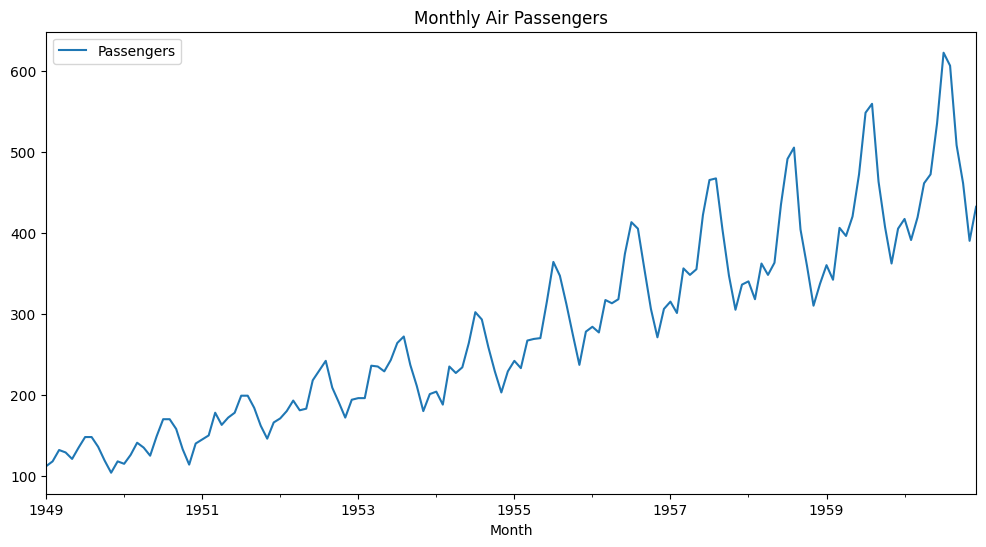

In [3]:
# Step 2: Load and Preprocess the Data

# Load dataset
df = pd.read_csv("AirPassengers.csv")

# Convert 'Month' to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Rename column for ease
df.rename(columns={"#Passengers": "Passengers"}, inplace=True)

# Plot the data
df.plot(figsize=(12, 6), title='Monthly Air Passengers')
plt.show()


In [4]:
# Step 3: Normalize the Data

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Passengers']])


In [5]:
# Step 4: Create Time Series Sequences

# Sequence generator
def create_dataset(data, time_step=12):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 12
X, y = create_dataset(scaled_data, time_step)

# Reshape X for LSTM: [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)


In [6]:
# Step 5: Train-Test Split

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [7]:
# Step 6: Build and Train the LSTM Model

model = Sequential()
model.add(LSTM(units=50, return_sequences=False, input_shape=(X.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0756 - val_loss: 0.1138
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0177 - val_loss: 0.0230
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0113 - val_loss: 0.0243
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0100 - val_loss: 0.0268
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0078 - val_loss: 0.0289
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0080 - val_loss: 0.0236
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0080 - val_loss: 0.0230
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0064 - val_loss: 0.0227
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0064 - val_loss: 0.0226
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0066 - val_loss: 0.0224
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0075 - val_loss: 0.0227
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0066 - val_loss: 0.0222
E

In [9]:
# Step 7: Predict and Inverse Transform

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


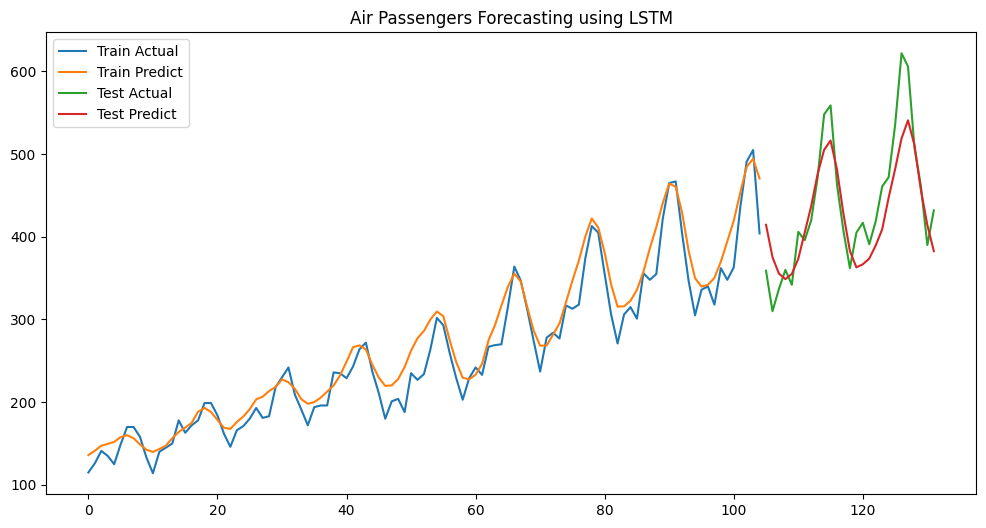

In [11]:
# Step 8: plotting the results

test_range = np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_actual))

plt.figure(figsize=(12,6))
plt.plot(np.arange(len(y_train_actual)), y_train_actual, label="Train Actual")
plt.plot(np.arange(len(y_train_actual)), train_predict, label="Train Predict")
plt.plot(test_range, y_test_actual, label="Test Actual")
plt.plot(test_range, test_predict, label="Test Predict")
plt.legend()
plt.title("Air Passengers Forecasting using LSTM")
plt.show()

